# Step 1 — Semantic Vectorization

**Goal:** produce a dense semantic embedding for every product in the Instacart catalog, so that products with similar descriptions land close together in vector space. This is the *substitute* signal of the thesis — two brands of almond milk should be near-neighbours even though their names differ.

We use the [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) model from `sentence-transformers` (384-dim output, fast, good general-purpose sentence encoder).

**Inputs** (`data/`): `products.csv`, `aisles.csv`, `departments.csv`

**Outputs** (`outputs/`):
- `products_text.csv` — products joined with aisle/department + a descriptive text column
- `embeddings.npy` — the embedding matrix, one row per product
- `product_id_to_index.json` — maps `product_id` to its row in the matrix

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Project root = parent of the notebooks/ directory.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)
STEP1_DIR = OUT_DIR / "step1"
STEP1_DIR.mkdir(parents=True, exist_ok=True)

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Load and join the catalog tables

`products.csv` references aisles and departments by id only. We join the two lookup tables so each product row carries the human-readable `aisle` and `department` labels, which we need as text for the embedding.

In [2]:
products = pd.read_csv(DATA_DIR / "products.csv")
aisles = pd.read_csv(DATA_DIR / "aisles.csv")
departments = pd.read_csv(DATA_DIR / "departments.csv")

catalog = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

print(f"{len(catalog):,} products")
catalog.head()

49,688 products


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


## 3. Build the descriptive text per product

We concatenate name, aisle, and department into one string. The aisle and department give the encoder category context that the bare product name lacks, e.g. `"Silk Unsweetened Almond Milk, soy lactose free, dairy eggs"`.

In [3]:
catalog["text"] = (
    catalog["product_name"].str.strip()
    + ", " + catalog["aisle"].str.strip()
    + ", " + catalog["department"].str.strip()
)

catalog[["product_id", "product_name", "aisle", "department", "text"]].head()

,product_id,product_name,aisle,department,text
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks,"Chocolate Sandwich Cookies, cookies cakes, snacks"
1,2,All-Seasons Salt,spices seasonings,pantry,"All-Seasons Salt, spices seasonings, pantry"
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages,"Robust Golden Unsweetened Oolong Tea, tea, bev..."
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,frozen,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,5,Green Chile Anytime Sauce,marinades meat preparation,pantry,"Green Chile Anytime Sauce, marinades meat prep..."


In [4]:
# Persist the joined table for downstream steps.
text_path = STEP1_DIR / "products_text.csv"
catalog.to_csv(text_path, index=False)
print("Saved", text_path)

Saved /Users/linnhtet/Developer/bachelor-thesis/outputs/products_text.csv


## 4. Load the model and select a device

Device priority: **MPS** (Apple Silicon) -> **CUDA** (NVIDIA GPU) -> **CPU**. The model is downloaded from HuggingFace Hub on first run and cached locally.

In [5]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("Using device:", device)

model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
model

Using device: mps


SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

## 5. Encode all products

We embed every product's text into a 384-dim vector. `normalize_embeddings=True` gives unit-length vectors, so a dot product equals cosine similarity later.

In [6]:
texts = catalog["text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Embedding matrix shape:", embeddings.shape)

Batches: 100%|█████████████████████████████████| 195/195 [00:13<00:00, 14.82it/s]

Embedding matrix shape: (49688, 384)


## 6. Save embeddings and the id->index lookup

Row `i` of `embeddings.npy` corresponds to `catalog.iloc[i]`. We store an explicit `product_id -> row index` map so downstream code never has to assume ordering.

In [7]:
emb_path = STEP1_DIR / "embeddings.npy"
np.save(emb_path, embeddings)

product_id_to_index = {
    int(pid): idx for idx, pid in enumerate(catalog["product_id"])
}
map_path = STEP1_DIR / "product_id_to_index.json"
with open(map_path, "w") as f:
    json.dump(product_id_to_index, f)

print("Saved", emb_path)
print("Saved", map_path)

Saved /Users/linnhtet/Developer/bachelor-thesis/outputs/embeddings.npy
Saved /Users/linnhtet/Developer/bachelor-thesis/outputs/product_id_to_index.json


## 7. Sanity check — nearest neighbours

Pick a few representative products and print their top-10 cosine neighbours. If the embedding space is sensible, the neighbours of a non-dairy milk should be other plant milks, a soda's neighbours should be other sodas, and so on — i.e. substitutes cluster together.

In [ ]:
index_to_pid = {idx: pid for pid, idx in product_id_to_index.items()}


def find_product(product_id):
    """Return the row index for the given `product_id`."""
    if product_id not in product_id_to_index:
        raise ValueError(f"No product with id {product_id!r}")
    return product_id_to_index[product_id]


def top_neighbours(row_idx, k=10):
    """Top-k most cosine-similar products to the given row (excluding itself)."""
    sims = cosine_similarity(embeddings[row_idx : row_idx + 1], embeddings)[0]
    order = np.argsort(-sims)
    order = [i for i in order if i != row_idx][:k]
    return catalog.iloc[order].assign(similarity=sims[order])


def show_neighbours(product_id, k=10):
    idx = find_product(product_id)
    print(f"Query: {catalog.iloc[idx]['text']}\n")
    cols = ["product_name", "aisle", "department", "similarity"]
    display(top_neighbours(idx, k)[cols].reset_index(drop=True))

In [ ]:
# A non-dairy milk: expect other plant-based milks.
show_neighbours(69)  # Vanilla with Almond Milk Iced Coffee

In [ ]:
# A soda: expect other soft drinks / colas.
show_neighbours(2479)  # Classic Coca Cola

In [ ]:
# A bread: expect other breads / bakery items.
show_neighbours(566)  # Organic Thin Sliced 100% Whole Wheat Bread

---
## 8. Reload artifacts and rebuild the product dataframe

The rest of the notebook visualises the embedding space. We reload the saved artifacts (`embeddings.npy`, `product_id_to_index.json`, `products_text.csv`) and rebuild a single dataframe with each product's name, aisle, department, and its embedding vector — so this section can run on its own in a fresh kernel.

In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Resolve outputs/ independently so this block can run in a fresh kernel.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

# Load the artifacts written earlier in this notebook.
emb = np.load(STEP1_DIR / "embeddings.npy")
with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}
products_text = pd.read_csv(STEP1_DIR / "products_text.csv")

# Rebuild a per-product dataframe and attach each product's 384-d vector.
# Align via the explicit product_id -> row map rather than trusting row order.
df = products_text[["product_id", "product_name", "aisle", "department"]].copy()
emb_aligned = emb[[pid_to_idx[pid] for pid in df["product_id"]]]
df["embedding"] = list(emb_aligned)

print(f"df: {df.shape[0]:,} products | embedding dim: {emb_aligned.shape[1]}")
df.head()

df: 49,688 products | embedding dim: 384


,product_id,product_name,aisle,department,embedding
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks,"[-0.045243468, 0.04178285, 0.054113362, 0.0659..."
1,2,All-Seasons Salt,spices seasonings,pantry,"[-0.10883936, -0.015302331, 0.020610739, 0.007..."
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages,"[-0.02904868, -0.04219622, 0.04766007, 0.08426..."
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,frozen,"[-0.08532191, -0.014000912, -0.00081382674, 0...."
4,5,Green Chile Anytime Sauce,marinades meat preparation,pantry,"[-0.023715919, -0.003105046, -0.030918235, 0.0..."


## 9. Reduce to 3D with UMAP

UMAP projects the 384-dimensional embeddings down to 3 dimensions for plotting, preserving local neighbourhood structure better than PCA. `random_state` is fixed so the layout is reproducible across runs.

In [13]:
import umap

RANDOM_STATE = 42

# n_components=3 -> 3D layout. metric="cosine" matches how we compare embeddings.
# A fixed random_state makes the layout reproducible (UMAP runs single-threaded
# in this mode, which is fine for a one-off projection of ~50k points).
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_STATE,
)
coords3d = reducer.fit_transform(emb_aligned)
print("3D coordinates:", coords3d.shape)

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


3D coordinates: (49688, 3)


## 10. Save the 3D coordinates

UMAP is the slow step, so we cache the 3D coordinates (plus product metadata) to `outputs/umap_3d.csv`. Reload that file to redraw the plots below without recomputing the projection.

In [14]:
# Attach 3D coords and persist metadata + coords (not the raw vectors).
df["umap_x"], df["umap_y"], df["umap_z"] = (
    coords3d[:, 0], coords3d[:, 1], coords3d[:, 2]
)

coords_path = STEP1_DIR / "umap_3d.csv"
df.drop(columns="embedding").to_csv(coords_path, index=False)
print("Saved", coords_path)

# To reload later without re-running UMAP:
#   df = pd.read_csv(STEP1_DIR / "umap_3d.csv")

Saved /Users/linnhtet/Developer/bachelor-thesis/outputs/umap_3d.csv


## 11. Interactive 3D scatter, coloured by department

Each point is a product, positioned by its UMAP coordinates and coloured by department. Hover to see the product name, aisle, and department; rotate and zoom to explore how departments separate in the embedding space.

In [15]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="umap_x", y="umap_y", z="umap_z",
    color="department",
    hover_name="product_name",
    hover_data={
        "aisle": True, "department": True,
        "umap_x": False, "umap_y": False, "umap_z": False,
    },
    title="Product embedding space (UMAP 3D), coloured by department",
    opacity=0.6,
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(height=800, legend=dict(itemsizing="constant"))
fig.show()

<plotly figure output removed for release>

## 12. Search & highlight substitutes

`SEARCH_PRODUCT_IDS` pins anchor products by exact `product_id` (looked up from `data/products.csv`), so the selection is unambiguous — substring matching is too brittle (e.g. `"Oat Milk"` is a substring of `"Goat Milk"`). For each anchor we find its nearest neighbours in the **full 384-d space** (not the lossy 3D projection) by cosine similarity, then highlight the anchors and their neighbours in the 3D plot.

The defaults are cross-category substitute pairs — dairy vs. plant-based yogurt, milk, and butter. Note this 2017 catalogue has no oat-milk beverage, so the dairy-milk substitute is **almond milk** (the mainstream plant milk of that era).

In [16]:
# ---- EDIT THIS LIST to explore different products ----
# Anchors are pinned by product_id (looked up from data/products.csv) so the
# selection is exact. Substring matching is too brittle: e.g. "Oat Milk" is a
# substring of "Goat Milk", and "Whole Milk" matches "Whole Milk Yogurt".
# Each consecutive pair is a cross-category substitute.
#
# NB: this 2017 Instacart catalogue has no oat-milk beverage, so the dairy-milk
# substitute below is almond milk (the mainstream plant milk of that era).
SEARCH_PRODUCT_IDS = [
    6104,   # Whole Milk Plain Yogurt    -- dairy yogurt
    920,    # Coconut Yogurt             ->  coconut yogurt
    4210,   # Whole Milk                 -- dairy milk
    6347,   # Unsweetened Almond Milk    ->  plant milk (no oat milk in catalogue)
    651,    # Organic Salted Butter      -- regular butter
    16268,  # Vegan Butter               ->  vegan butter
]
N_NEIGHBORS = 10

# Map product_id -> row position in df / emb_aligned (they are row-aligned).
pid_to_row = {pid: pos for pos, pid in enumerate(df["product_id"])}


def neighbours_full_space(pos, k=N_NEIGHBORS):
    """Top-k nearest products to `pos` by cosine similarity in the full 384-d space."""
    sims = cosine_similarity(emb_aligned[pos:pos + 1], emb_aligned)[0]
    order = [i for i in np.argsort(-sims) if i != pos][:k]
    return order, sims


highlight = set()
records = []
for pid in SEARCH_PRODUCT_IDS:
    pos = pid_to_row.get(pid)
    if pos is None:
        print(f"[skip] product_id {pid} not found")
        continue
    nbrs, sims = neighbours_full_space(pos)
    highlight.add(pos)
    highlight.update(nbrs)
    anchor_name = df.iloc[pos]["product_name"]
    print(f"{pid} -> anchor: {anchor_name}")
    for r in nbrs:
        records.append({
            "anchor": anchor_name,
            "neighbour": df.iloc[r]["product_name"],
            "aisle": df.iloc[r]["aisle"],
            "department": df.iloc[r]["department"],
            "similarity": round(float(sims[r]), 4),
        })

results = pd.DataFrame(records)
print(f"\n{len(highlight)} products highlighted "
      f"({len(SEARCH_PRODUCT_IDS)} anchors x up to {N_NEIGHBORS} neighbours).")

# Show top-5 neighbours per anchor product for easier relevance checking.
top5_per_anchor = (
    results
    .sort_values(["anchor", "similarity"], ascending=[True, False])
    .groupby("anchor", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)
display(top5_per_anchor)

6104 -> anchor: Whole Milk Plain Yogurt
920 -> anchor: Coconut Yogurt
4210 -> anchor: Whole Milk
6347 -> anchor: Unsweetened Almond Milk
651 -> anchor: Organic Salted Butter
16268 -> anchor: Vegan Butter

62 products highlighted (6 anchors x up to 10 neighbours).


,anchor,neighbour,aisle,department,similarity
0,Coconut Yogurt,Coconut Yoghurt,yogurt,dairy eggs,0.9598
1,Coconut Yogurt,Vanilla Coconut Milk Yogurt,yogurt,dairy eggs,0.9481
2,Coconut Yogurt,Organic Coconut Yogurt,yogurt,dairy eggs,0.9453
3,Coconut Yogurt,Strawberry Banana Coconut Milk Yogurt,yogurt,dairy eggs,0.9319
4,Coconut Yogurt,Yogurt Almond Milk Coconut,milk,dairy eggs,0.9296
5,Organic Salted Butter,Organic Lightly Salted Butter,butter,dairy eggs,0.9795
6,Organic Salted Butter,Organic Unsalted Butter,butter,dairy eggs,0.9356
7,Organic Salted Butter,Organic Unsalted Butter,butter,dairy eggs,0.9356
8,Organic Salted Butter,Salted Butter,butter,dairy eggs,0.9313
9,Organic Salted Butter,Organic European Style Lightly Salted Butter,butter,dairy eggs,0.9270


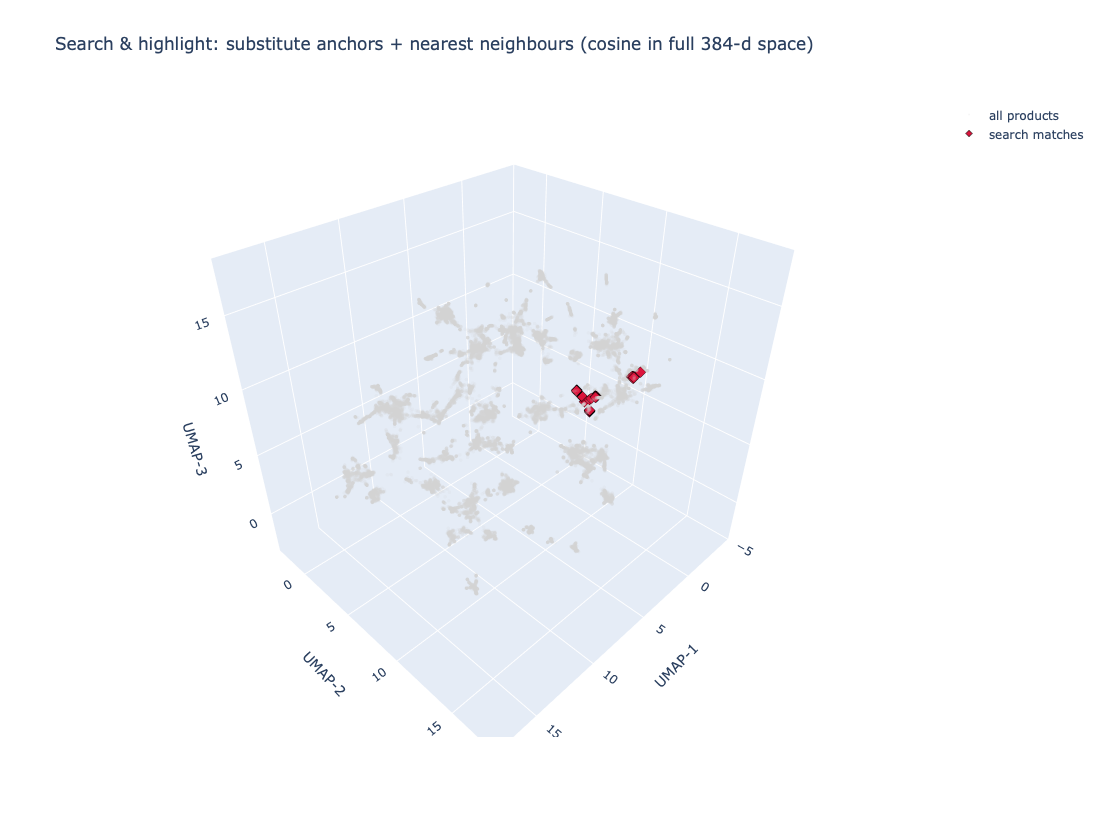

In [17]:
import plotly.graph_objects as go

mask = np.zeros(len(df), dtype=bool)
mask[sorted(highlight)] = True
base, hi = df[~mask], df[mask]

fig = go.Figure()

# Context: the rest of the catalogue in faint grey.
fig.add_trace(go.Scatter3d(
    x=base["umap_x"], y=base["umap_y"], z=base["umap_z"],
    mode="markers",
    marker=dict(size=2, color="lightgrey", opacity=0.12),
    name="all products",
    hovertext=base["product_name"], hoverinfo="text",
))

# Highlighted: anchors + their nearest neighbours, in a distinct colour/marker.
fig.add_trace(go.Scatter3d(
    x=hi["umap_x"], y=hi["umap_y"], z=hi["umap_z"],
    mode="markers",
    marker=dict(size=5, color="crimson", symbol="diamond",
                line=dict(width=0.5, color="black")),
    name="search matches",
    customdata=hi[["aisle", "department"]].to_numpy(),
    hovertext=hi["product_name"],
    hovertemplate="<b>%{hovertext}</b><br>aisle: %{customdata[0]}"
                  "<br>department: %{customdata[1]}<extra></extra>",
))

fig.update_layout(
    title="Search & highlight: substitute anchors + nearest neighbours "
          "(cosine in full 384-d space)",
    height=800,
    scene=dict(xaxis_title="UMAP-1", yaxis_title="UMAP-2", zaxis_title="UMAP-3"),
)
fig.show()